In [ ]:
import sys
print(sys.executable)
#SE NON VEDI "sam2env" NEL KERNEL LIST
#C:\Users\lore\sam2env\Scripts\activate
#pip install ipykernel
#python -m ipykernel install --user --name sam2env --display-name "Python 3.11 (sam2env)"

c:\Users\lore\sam2env\Scripts\python.exe


In [1]:
import torch
import numpy as np
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SCELTA CHECPOINT E MODEL CONFIGURATION

#checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

#checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

#checkpoint = "../checkpoints/sam2.1_hiera_base_plus.pt"
#model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

device = "cuda"
model = build_sam2(model_cfg, checkpoint, device=device)
predictor = SAM2ImagePredictor(model)
print(torch.cuda.is_available())

True


In [2]:
# Carica immagine
#img_name = "img/flamingo4.png" #non vede il fenicottero
#img_name = "img/bird4.png" #bene
#img_name = "img/acoustic_guitar.png" #magari aumentare k

#img_name = "img/boat.jpg" #non riconosce la barca
#img_name = "img/donuts.jpg" #bene
#img_name = "img/elephant.jpg" #bene
#img_name = "img/teddy_bear.jpg" #bene
#img_name = "img/desk.jpg" #mh, magari aumentare top_k
#img_name = "img/pizza.jpg" #bene
#img_name = "img/lunch.jpg" #bene
img_name = "img/people.jpg" #bene

image = Image.open(img_name).convert("RGB")
image = np.array(image)

In [3]:
with torch.inference_mode():
    predictor.set_image(image)

MASCHERE

In [63]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# -------------------------------------------------
# DEFAULT (baseline SAM2 senza modifiche)
# -------------------------------------------------
mask_generator_default = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)


mask_generator_m2m = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=True,#false
    multimask_output=True,
)

mask_generator_iou = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.7,#0.08
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_score = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.80,#0.95
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_nmsboxt = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.5,#0.7
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_maskt = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=1.0,#0.0

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_scoreoffset = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=2.0,#1.0

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_nmscropt = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.5,#0.7
    crop_overlap_ratio=512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)

mask_generator_overlapr = SAM2AutomaticMaskGenerator(
    model,

    points_per_side=32,
    points_per_batch=64,

    pred_iou_thresh=0.8,
    stability_score_thresh=0.95,
    stability_score_offset=1.0,

    mask_threshold=0.0,

    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=0.5,#512 / 1500,
    crop_n_points_downscale_factor=1,

    point_grids=None,
    min_mask_region_area=0,

    output_mode="binary_mask",

    use_m2m=False,
    multimask_output=True,
)
# -------------------------------------------------
# CONFIGS USATE IN PIPELINE (SENZA DUPLICATI)
# -------------------------------------------------
configs = {
    "default": mask_generator_default,
    "m2m" : mask_generator_m2m,
    "iou": mask_generator_iou,
    "score": mask_generator_score,
    "nmsboxt" : mask_generator_nmsboxt,
    "maskt" : mask_generator_maskt,
    "screoffset" : mask_generator_scoreoffset,
    "nmscropt" : mask_generator_nmscropt,
    "overlapr" : mask_generator_overlapr,
}

PREDIZIONE MASCHERE E LE SALVO IN RESULT (Default)

In [64]:
import time

results = {}

for name, gen in configs.items():
    start_time = time.time()
    print(f"\nStarting {name}...")
    masks = gen.generate(image)

    end_time = time.time()
    elapsed = end_time - start_time

    minutes = int(elapsed // 60)
    seconds = elapsed % 60

    print(f"{name}: {minutes} min {seconds:.2f} sec")

    results[name] = masks


Starting default...
default: 0 min 3.71 sec

Starting m2m...
m2m: 0 min 12.27 sec

Starting iou...
iou: 0 min 3.55 sec

Starting score...
score: 0 min 3.93 sec

Starting nmsboxt...
nmsboxt: 0 min 3.80 sec

Starting maskt...
maskt: 0 min 3.71 sec

Starting screoffset...
screoffset: 0 min 3.57 sec

Starting nmscropt...
nmscropt: 0 min 3.90 sec

Starting overlapr...
overlapr: 0 min 3.76 sec


SCEGLIERE UNO DI QUESTI ORDINAMENTI

In [65]:
import math
#ORDINAMENTI COMBINATI
#Ranking completo (quello più “production-like”)
def full_sort(masks):
    return sorted(masks,key=lambda x: (x["predicted_iou"]* x["stability_score"]* math.log(x["area"] + 1)),reverse=True)

#Ranking combinato qualità + dimensione
def quality_dim_sort(masks):
    return  sorted(masks,key=lambda x: x["predicted_iou"] * math.log(x["area"] + 1), reverse=True)

#Ranking qualità + stabilità
def quality_stability_sort(masks):
    return  sorted(masks,key=lambda x: x["predicted_iou"] * x["stability_score"],reverse=True)


In [66]:
# ORDINAMENTI SINGOLI
# ordina per qualità stimata della maschera
def iou_sort(masks):
    return sorted(masks, key=lambda x: x["predicted_iou"], reverse=True)


# Ordinamento per area
def area_sort(masks):
    return sorted(masks, key=lambda x: x["area"], reverse=True)


# Ordinamento per stability score
def stability_sort(masks):
    return sorted(masks, key=lambda x: x["stability_score"], reverse=True)

In [67]:
# ORDINAMENTI SPECIFICI
# Ordinamento per bounding box size
def box_size_sort(masks):
    return sorted(masks,key=lambda x: x["bbox"][2] * x["bbox"][3],reverse=True)

# Ordinamento custom “object-centric”
def score(m):
    return (m["predicted_iou"]* m["stability_score"]* np.sqrt(m["area"]))
def object_centric_sort(masks):
    return sorted(masks, key=score, reverse=True)

In [68]:
SORT_METHODS = {
    "full": full_sort,
    "quality_dim": quality_dim_sort,
    "quality_stability": quality_stability_sort,
    "iou": iou_sort,
    "area": area_sort,
    "stability": stability_sort,
    "box_size": box_size_sort,
    "object_centric": object_centric_sort,
}

ORDINAMENTO DEL RESULT

In [69]:
ranked_results = {}

selected_sort = "full"
sort_fn = SORT_METHODS[selected_sort]

for name, masks in results.items():
    ranked_results[name] = sort_fn(masks)

SCELTA PRIME K MASCHERE + PLOT

In [70]:
top_k = 100

top_results = {
    name: masks[:min(top_k, len(masks))]
    for name, masks in ranked_results.items()
}

In [71]:
import matplotlib.pyplot as plt

configs = list(top_results.keys())
n_rows = len(configs)
n_cols = max(len(v) for v in top_results.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

if n_rows == 1:
    axes = [axes]

for r, config_name in enumerate(configs):

    masks = top_results[config_name]
    n = len(masks)

    for c in range(n_cols):

        ax = axes[r][c] if n_rows > 1 else axes[c]

        ax.axis("off")

        # nome configurazione a sinistra
        if c == 0:
            ax.set_title(
                f"{config_name} ({n})",
                fontsize=14,
                fontweight="bold",
                loc="left"
            )

        if c < n:

            mask = masks[c]
            seg = mask["segmentation"]

            ax.imshow(image)
            ax.imshow(seg, alpha=0.5, cmap="jet")

            ax.set_title(
                f"Mask {c+1}\n"
                f"IoU: {mask['predicted_iou']:.2f}\n"
                f"A: {mask['area']}\n"
                f"S: {mask['stability_score']:.2f}",
                fontsize=8
            )

plt.tight_layout()
plt.show()

PLOT STATISTICHE

In [72]:
import numpy as np

def compute_metrics(masks):
    areas = np.array([m["area"] for m in masks])
    ious = np.array([m["predicted_iou"] for m in masks])
    stabs = np.array([m["stability_score"] for m in masks])

    return {
        "num_masks": len(masks),
        "avg_iou": float(ious.mean()),
        "avg_stability": float(stabs.mean()),
        "small_masks_ratio": float((areas < 2000).mean()),
        "large_masks_ratio": float((areas > 20000).mean()),
    }


In [73]:
comparison_data = []

for config_name, masks in top_results.items():
    m = compute_metrics(masks)
    m["config"] = config_name
    comparison_data.append(m)

In [74]:
configs = [d["config"] for d in comparison_data]
num_masks = [d["num_masks"] for d in comparison_data]
avg_iou = [d["avg_iou"] for d in comparison_data]
avg_stability = [d["avg_stability"] for d in comparison_data]
detail_score_s = [d["small_masks_ratio"] for d in comparison_data]
detail_score_l = [d["large_masks_ratio"] for d in comparison_data]

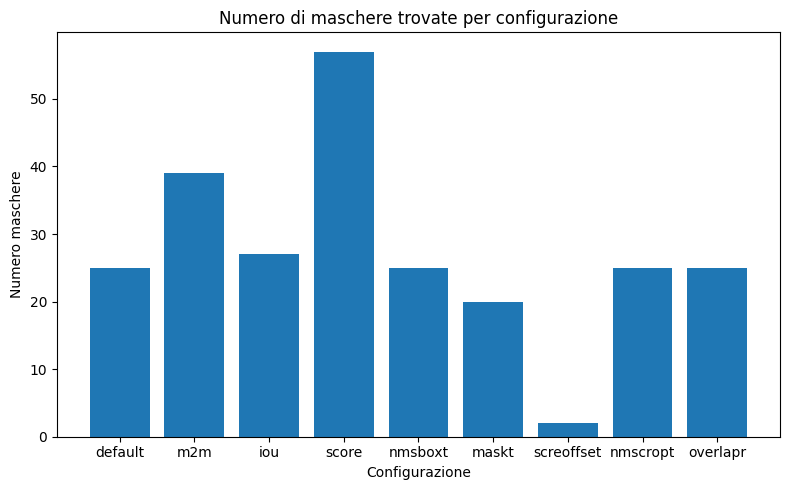

In [75]:
import matplotlib.pyplot as plt
import numpy as np

configs = [d["config"] for d in comparison_data]
num_masks = [d["num_masks"] for d in comparison_data]

plt.figure(figsize=(8,5))
plt.bar(configs, num_masks)
plt.title("Numero di maschere trovate per configurazione")
plt.ylabel("Numero maschere")
plt.xlabel("Configurazione")
plt.tight_layout()
plt.show()

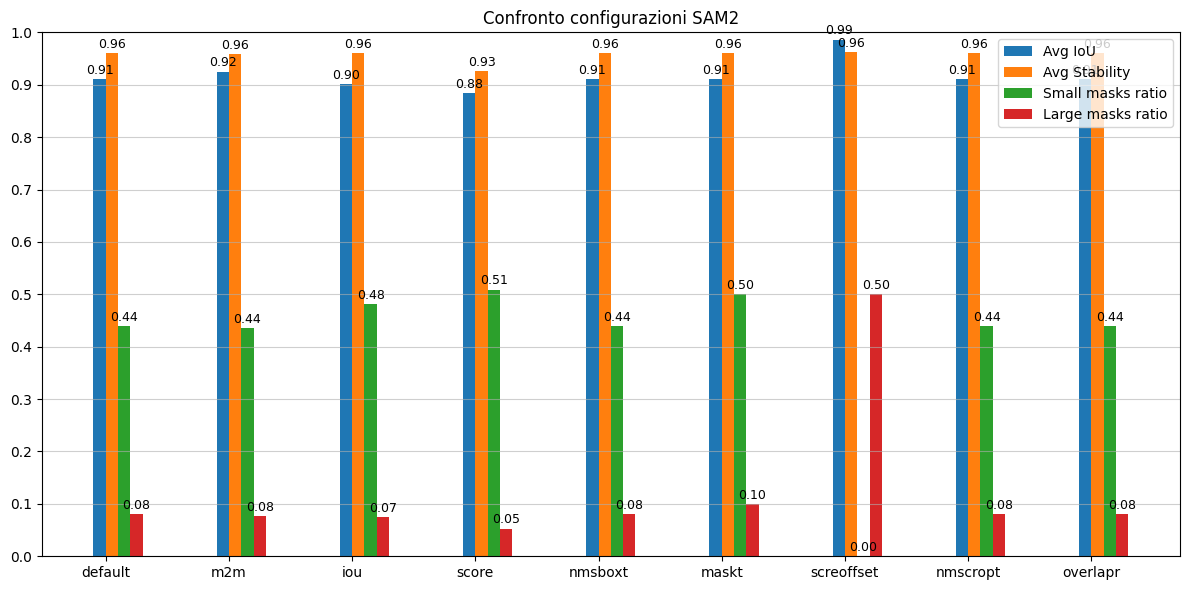

In [76]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(configs))
width = 0.1

plt.figure(figsize=(12, 6))

plt.bar(x - 0.5*width, avg_iou, width, label="Avg IoU")
plt.bar(x + 0.5*width, avg_stability, width, label="Avg Stability")
plt.bar(x + 1.5*width, detail_score_s, width, label="Small masks ratio")
plt.bar(x + 2.5*width, detail_score_l, width, label="Large masks ratio")

for i, v in enumerate(avg_iou):
    plt.text(x[i] - 0.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(avg_stability):
    plt.text(x[i] + 0.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(detail_score_s):
    plt.text(x[i] + 1.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(detail_score_l):
    plt.text(x[i] + 2.5*width, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

plt.xticks(x, configs)
plt.title("Confronto configurazioni SAM2")
plt.grid(axis="y", linestyle="-", alpha=0.6)
plt.legend()
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.tight_layout()
plt.show()

**PREDIZIONE GREZZA**
```md
IMAGE
  ↓
Image Encoder (ViT)
  ↓
IMAGE EMBEDDING
  ↓
+ PROMPT (point/box)
  ↓
Mask Decoder
  ↓
LOGITS (pixel-wise raw scores)
  ↓
SIGMOID + THRESHOLD
  ↓
MASK (binary)
  ↓
IoU Head → SCORE (quality prediction)
```

In [77]:
input_point = np.array([[100, 75]])
input_label = np.array([1])

**SamAutomaticMaskGenerator**
```md
genera tantissimi punti
↓
chiama predict() molte volte
↓
filtra overlap
↓
ritorna tutte le masks
```

**PREDICT**
```md
point_coords -> segmenta qualcosa nelle coordinate date
multimask_output=True -> produce più ipotesi
return_logits=True -> ritorna anche output grezzo decoder (logits)
```

| output | origine                    |
| ------ | -------------------------- |
| logits | mask decoder               |
| scores | IoU head                   |
| masks  | threshold + upscale logits |
```md
IMAGE
↓
set_image()
↓
Image Encoder (ViT, vision transformer) [l’immagine grezza in una rappresentazione numerica “comprensibile” al modello.prende i pixel e li converte in embedding semantici.]
↓
IMAGE EMBEDDING salvato

predict()
↓
Riceve prompt (point / box / mask)
↓
Prompt Encoder
↓
Converte il prompt in embeddings
↓
Mask Decoder
↓
Genera logits (pixel-wise raw scores)
↓
IoU Head
↓
Stima qualità delle masks (scores)
↓
Postprocessing
(upscale + threshold)
↓
Ritorna:
- masks
- scores
- logits
```

**DIFFERENZE**

| predict()             | AutomaticMaskGenerator   |
| --------------------- | ------------------------ |
| guidato da prompt     | completamente automatico |
| una zona specifica    | tutta l’immagine         |
| poche masks candidate | centinaia/migliaia       |
| interattivo           | batch automatico         |


In [78]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
    return_logits=True
)

**STAMPO SCORE**

SAM predice quanto la mask generata dovrebbe matchare una “vera” segmentazione.
Il modello cerca di stimare la:

IoU=∣A∪B∣ / ∣A∩B∣
A = mask predetta
B = mask ideale (non conosciuta)

| score   | significato             |
| ------- | ----------------------- |
| > 0.95  | mask molto affidabile   |
| 0.8–0.9 | buona                   |
| 0.6–0.8 | ambigua                 |
| < 0.5   | probabilmente sbagliata |

Perché SAM genera più ipotesi: il modello “prova più segmentazioni possibili”

**IoU**
```md
IoU NON è un output del modello. È una misura esterna di qualità. Quanto due maschere si sovrappongono: uno è la predizione del modello; uno è la “verità”
COSA IMPARA IN TRAINING

Durante training:

SAM produce una mask
si calcola IoU reale con ground truth:

IoU=∣ M pred ​∪ Mgt ​∣ / ∣ Mpred​ ∩ Mgt ​∣

quindi la loss è:differenza tra score predetto e IoU reale


image + prompt
        ↓
image encoder
        ↓
mask decoder → logits → masks
        ↓
IoU head → score


In fase di training SAM impara la IoU Head ("prediction head"): prende in input la rappresentazione della maschera candidata + contesto
e predice quanto quella maschera è buona -> il risultato è lo score OUTPUT un singolo numero: score ∈ [0, 1]

La IoU head è una rete che, durante il training, impara a predire la qualità (IoU) di una maschera; in inference produce lo score, che è solo una stima di quella qualità, non una misura reale.

INPUT della IoU head

Non guarda solo la mask “da sola”, ma tipicamente:

image embedding (informazione dell’immagine)
prompt embedding (punti/box)
embedding della maschera candidata (dal decoder)
```

In [79]:
for i, score in enumerate(scores):
    print(f"Mask {i}: score = {score}")

Mask 0: score = 0.15184186398983002
Mask 1: score = 0.9833352565765381
Mask 2: score = 0.9384284615516663


**STAMPO LOGITS**
```md
Una mappa continua di valori reali (NO PROBABILITA'):

shape: 256 × 256 (low resolution)
valori: da circa -10 → +10 (non limitati)

molto positivo (+5, +8) -> pixel sicuramente dentro l’oggetto
vicino a 0 -> incerto
molto negativo (-5, -8) -> background

DI DEFAULT
mask = sigmoid(logits) > 0.5
```

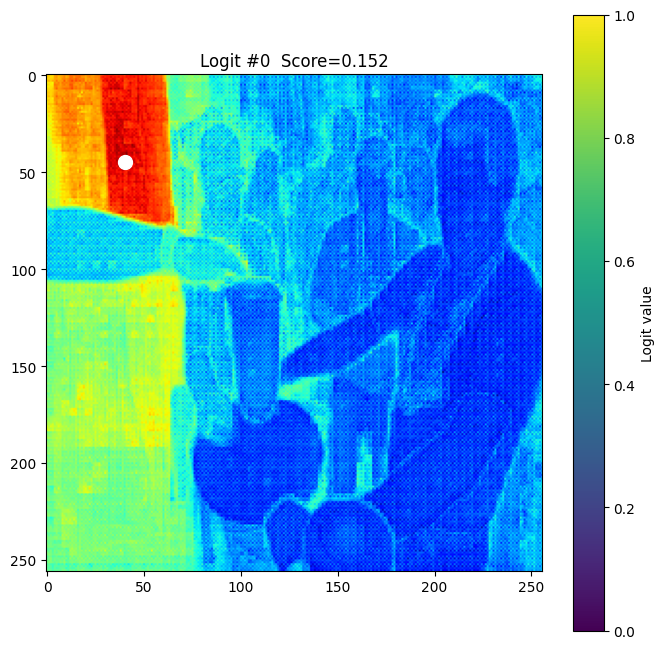

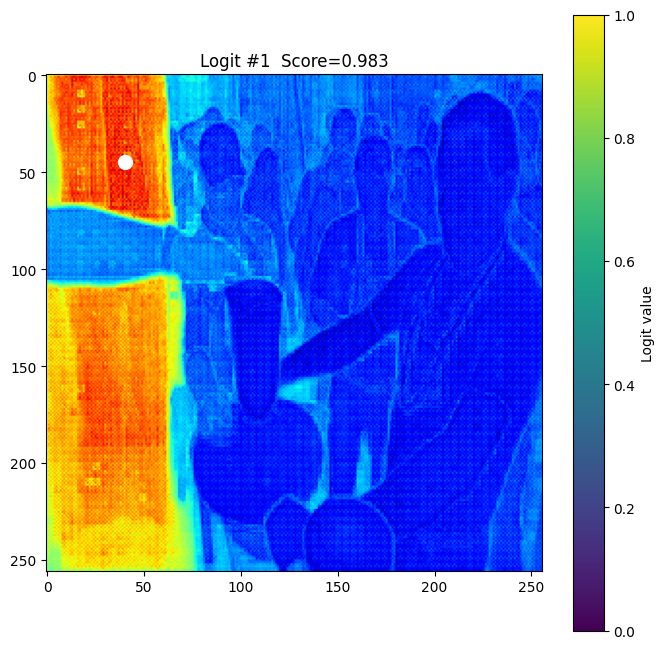

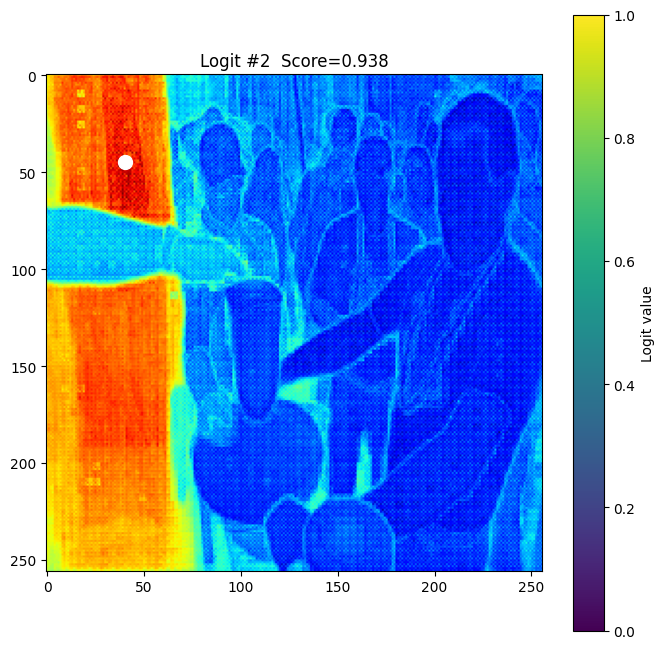

In [80]:
import matplotlib.pyplot as plt


for i, logit in enumerate(logits):

    plt.figure(figsize=(8, 8))

    plt.title(f"Logit #{i}  Score={scores[i]:.3f}")

    # logit grezzo
    plt.imshow(logit, cmap="jet")

    # punto input
    plt.scatter(
        input_point[:, 0] / image.shape[1] * 256,
        input_point[:, 1] / image.shape[0] * 256,
        color="white",
        s=100
    )

    plt.colorbar(label="Logit value")

    plt.show()

**STAMPO MASCHERE (MASK)**
```md
Una matrice:
dimensione: H × W
valori: True / False (o 1/0)
Significato

Per ogni pixel:

“questo pixel appartiene all’oggetto oppure no?”

Deriva dai logits:
logits → threshold → masks
```

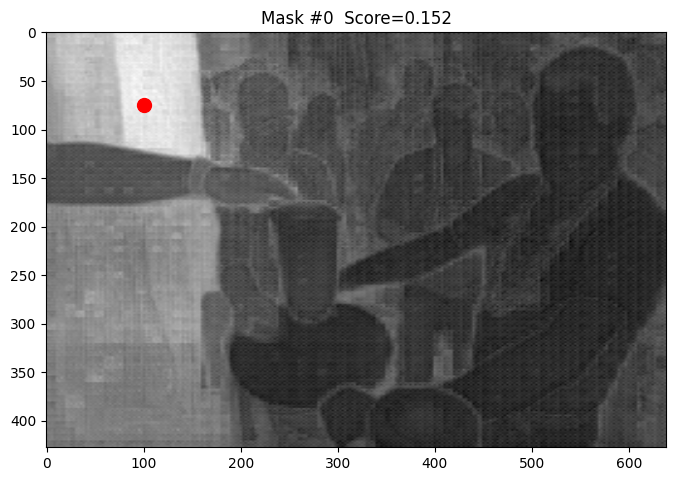

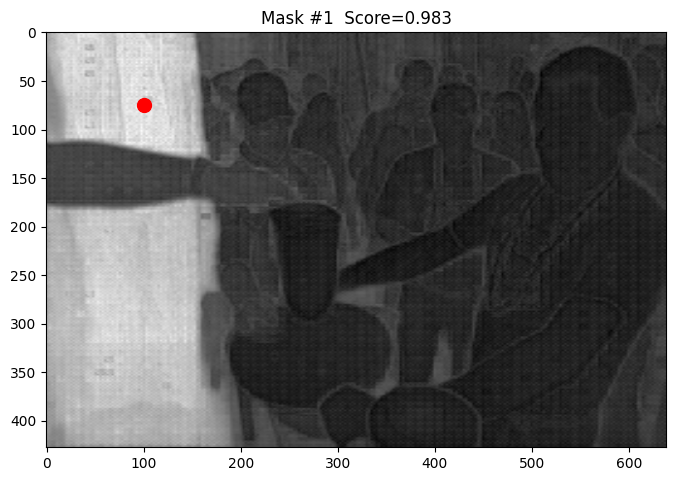

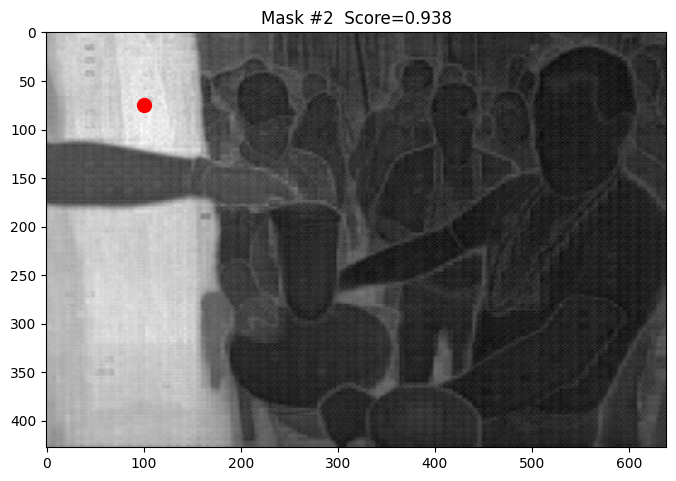

In [81]:
import matplotlib.pyplot as plt

for i, mask in enumerate(masks):

    plt.figure(figsize=(8, 8))

    plt.title(f"Mask #{i}  Score={scores[i]:.3f}")

    # mask binaria
    plt.imshow(mask, cmap="gray")

    # punto input
    plt.scatter(
        input_point[:, 0],
        input_point[:, 1],
        color="red",
        s=100
    )

    plt.show()